# Практика 5. Задача классификации. Дискриминантные модели, метод ближайших соседей.

Сегодня на практике мы познакомимся с задачей классификации объектов. Формально задача ставится следующим образом: имеется набор данных $D=\{(x_i,y_i)\}_{i=1}^n, y_i=\{C_1,\dots,C_M\}$, то есть имеется набор точек $X$ в некотором пространстве и набор меток классов $Y$. Каждая точка $x$ принадлежит одному из $M$ классов. Задача состоит в построении модели для предсказания меток классов для точек.

Пока рассмотрим вариант, где классов всего два, а потом перейдём к примерам сложнее.

Интуитивно, задача сводится к тому, что нам необходимо получить поверхность, которая разделяла бы объекты на заданные классы. Самой первой и простой идеей выступает построение линейной разделяющей поверхности, которая задаётся уравнением $wx+w_0=0$.

## Метод наименьших квадратов

Но коэффициенты уравнения необходимо как-то получить. Можно попробовать воспользоваться тем, что вы уже знаем $-$ линейной регрессией. Скажем, что для всех объектов первого класса целевая переменная $y=-1$, а для всех объектов второго $y=1$, а далее обучим регрессию методом наименьших квадратов.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.datasets import load_iris

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
def orthogonal_example(n_points, mean, cov, target):
    X = []
    Y = []
    # Генерация точек из каждого гауссиана
    for i in range(0, n_points.shape[0]):
        X.append(np.random.multivariate_normal(mean=mean[i], cov=cov[i], size=n_points[i]))
        Y.append(np.ones(n_points[i])*target[i])
    X = np.concatenate(X)
    Y = np.concatenate(Y)
    # Обучение модели
    model = LinearRegression()
    model.fit(X, Y)
    # рисование разделяющей прямой
    x1 = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
    x2 = (-model.coef_[0] * x1 - model.intercept_) / model.coef_[1]
    plt.plot(x1, x2, color='r', linewidth=2)
    # рисование точек данных
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, legend=False)
    plt.xlim(X[:,0].min()-1, X[:,0].max()+1)
    plt.ylim(X[:,1].min()-1, X[:,1].max()+1)

Пример с одинаковым количеством точек и одинаковой ковариацией. В это случае всё работает прекрасно.

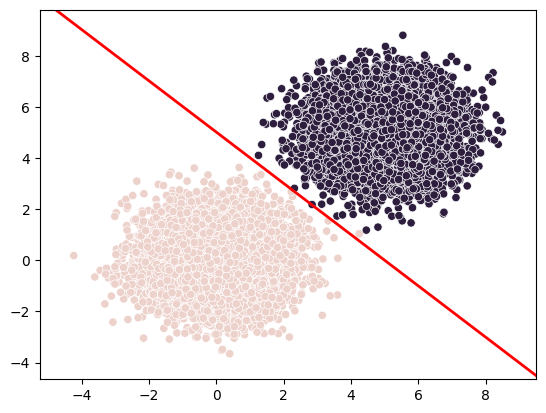

In [ ]:
# Задаём параметры для генерации точек
# Количество точек
n_points = np.array([10000, 10000])
target = np.array([-1, 1])
# Среднее центров гауссианов
mean = np.array([[0, 0], [5, 5]])
# Матрицы коварианцй
cov = np.array(
    [[[1, 0],
      [0, 1]],
     [[1, 0],
      [0, 1]]]
    )
orthogonal_example(n_points, mean, cov, target)

А вот при разных ковариациях начинает проявляться "глупость" такого метода:

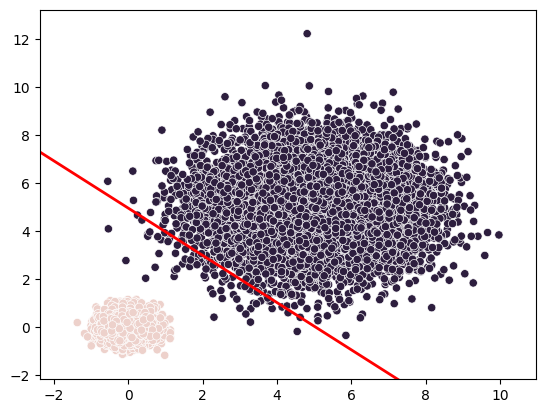

In [ ]:
# Задаём параметры для генерации точек
# Количество точек
n_points = np.array([10000, 10000])
target = np.array([-1, 1])
# Среднее центров гауссианов
mean = np.array([[0, 0], [5, 5]])
# Матрицы коварианцй
cov = np.array(
    [[[0.1, 0],
      [0, 0.1]],
     [[2, 0],
      [0, 2]]]
    )
orthogonal_example(n_points, mean, cov, target)

А при появлении ещё одного облака точек в той области, где они и так верно классифицируются, результат резко ухудшается, хотя кажется что добавление таких точек не должно сильно влиять на классификатор.

Происходит это именно из-за того, что используемый метод стремится сделать так, чтобы точки обоих классов были сосредоточены на одинаковом расстоянии от прямой, но по разные стороны. Такая модель предполагает, что у нас имеется 2 класса, каждый из которых распределён нормально, и с одинаковыми матрицами ковариаций. Мы эти предположения нарушили и метод перестал работать.

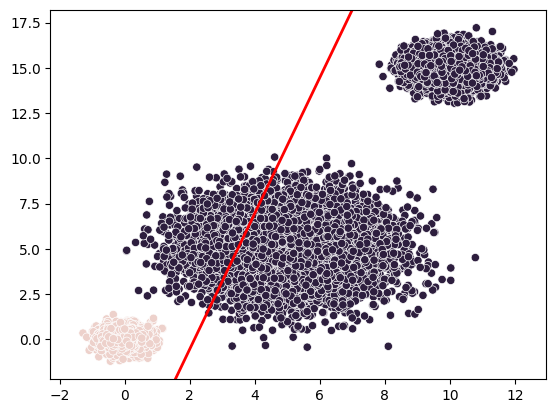

In [ ]:
# Задаём параметры для генерации точек
# Количество точек
n_points = np.array([10000, 10000, 10000])
target = np.array([-1, 1, 1])
# Среднее центров гауссианов
mean = np.array([[0, 0], [5, 5], [10, 15]])
# Матрицы коварианцй
cov = np.array(
    [[[0.1, 0],
      [0, 0.1]],
     [[2, 0],
      [0, 2]],
     [[0.3, 0],
      [0, 0.3]]]
    )
orthogonal_example(n_points, mean, cov, target)

## Метод серединного перпендикуляра

Продолжая геометрическую идею классификации, можно заметить, что задача сводится к тому, что мы хотим построить такую гиперплоскость, при проецировании точек на нормаль которой, точки бы хорошо разделялись. Хорошей идеей было бы максимизировать расстояние между классами, то есть максимизировать значение $$|w^T(m_1-m_2)|,$$ где $m_1$ и $m_1$ это центры классов, находимые по формулам:

$$m_1=\frac{1}{|С_1|}\sum_{x_n\in C_1}x_n, \;\; m_2=\frac{1}{|C_2|}\sum_{x_n\in C_2}x_n.$$

Ограничим норму вектора единицей $||w||=1$, так как максимизация $|w^T(m_1-m_2)|$ может достигаться простым увеличением $w$.

In [ ]:
def orthogonal_example(n_points, mean, cov, target):
    X = []
    Y = []
    # Генерация точек из каждого гауссиана
    for i in range(0, n_points.shape[0]):
        X.append(np.random.multivariate_normal(mean=mean[i], cov=cov[i], size=n_points[i]))
        Y.append(np.ones(n_points[i])*target[i])
    X = np.concatenate(X)
    Y = np.concatenate(Y)
    # ВЫчисление средних кластеров
    m1 = np.mean(X[np.where(Y==-1)],axis=0)
    m2 = np.mean(X[np.where(Y==1)],axis=0)
    # Отрисовка центров и соединяющей их линии
    plt.scatter([m1[0],m2[0]], [m1[1],m2[1]], zorder=100, marker="*", s=200)
    plt.plot([m1[0],m2[0]], [m1[1],m2[1]], zorder=199, linestyle="dashed", lw=3)
    
    # вектор нормали
    w = (m1 - m2) / np.sqrt(np.sum(np.square(m1-m2)))
    # смещение прямой
    w0 = -1/2 * np.sum(m1**2 - m2**2) / np.sqrt(np.sum(np.square(m1 - m2)))
    x1 = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
    x2 = -(w[0] * x1 + w0) / w[1]
    plt.plot(x1, x2, color='r', linewidth=2)
    # рисование точек данных
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, legend=False)
    plt.gca().set_aspect("equal") # фиксированное соотношение сторон, чтобы сохранялись углы 90
    plt.xlim(X[:,0].min()-1, X[:,0].max()+1)
    plt.ylim(X[:,1].min()-1, X[:,1].max()+1)

И снова для случая с одинаковыми ковариациями всё хорошо.

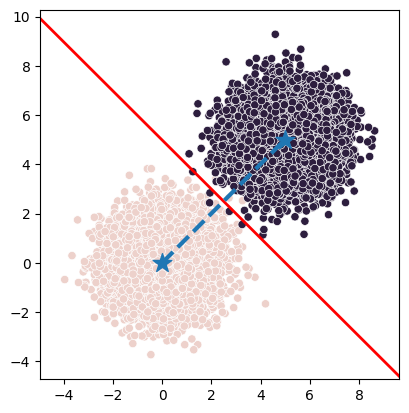

In [ ]:
# Задаём параметры для генерации точек
# Количество точек
n_points = np.array([10000, 10000])
target = np.array([-1, 1])
# Среднее центров гауссианов
mean = np.array([[0, 0], [5, 5]])
# Матрицы коварианцй
cov = np.array(
    [[[1, 0],
      [0, 1]],
     [[1, 0],
      [0, 1]]]
    )
orthogonal_example(n_points, mean, cov, target)

Случай с с несколькими облаками точек в одном классе рассматривать при таком методе будет совсем не релевантно, а вот случай разной дисперсии по разным координатам стоит отметить. В таком случае, становится понятно, что построение серединного перпендикуляра всё же не лучшее решение.

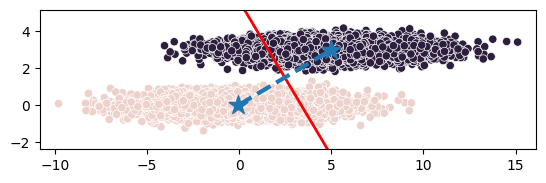

In [ ]:
# Задаём параметры для генерации точек
# Количество точек
n_points = np.array([10000, 10000])
target = np.array([-1, 1])
# Среднее центров гауссианов
mean = np.array([[0, 0], [5, 3]])
# Матрицы коварианцй
cov = np.array(
    [[[6, 0],
      [0, 0.1]],
     [[6, 0],
      [0, 0.1]]]
    )
orthogonal_example(n_points, mean, cov, target)

## Линейный дискриминант Фишера

Получается, что максимизации одного расстояния между классами недостаточно, необходимо минимизировать перекрытие классов, то есть выбрать ту проекцию, где разброс каждого из классов меньше.

$$s_1^2 = \sum_{x_n\in C_1}(w^Tx_n-\mu_1)^2, \;\; s_2^2 = \sum_{x_n\in C_2}(w^Tx_n-\mu_2)^2, $$
где $\mu_1$ и $\mu_2$ это центры классов в проекции на вектор нормали:

$$\mu_1=\frac{1}{|C_1|}\sum_{x_n\in C_1}w^Tx_n, \;\; \mu_2=\frac{1}{|C_2|}\sum_{x_n\in C_2}w^Tx_n.$$

Получается, что мы хотим:

- максимизировать расстояние между классами $|w^T(m_1-m_2)|$
- минимизировать суммарный разброс $s_1^2+s_2^2$

Поэтому будем максимизировать отношение этих величин:

$$J(w)=\frac{w^T(m_1-m_2)(m_1-m_2)^Tw}{s_1^2+s_2^2}$$

Опустим тонкости минимизации этой функции ошибки, оно подробно разбиралось на лекции.

In [ ]:
def fisher_example(n_points, mean, cov, target):
    X = []
    Y = []
    # Генерация точек из каждого гауссиана
    for i in range(0, n_points.shape[0]):
        X.append(np.random.multivariate_normal(mean=mean[i], cov=cov[i], size=n_points[i]))
        Y.append(np.ones(n_points[i])*target[i])
    X = np.concatenate(X)
    Y = np.concatenate(Y)
    # Обучение модели
    model = LinearDiscriminantAnalysis()
    model.fit(X, Y)
    
    m1=model.means_[0]
    m2=model.means_[1]
    plt.scatter([m1[0],m2[0]], [m1[1],m2[1]], zorder=100, marker="*", s=200)
    plt.plot([m1[0],m2[0]], [m1[1],m2[1]], zorder=199, linestyle="dashed", lw=3)
    # рисование разделяющей прямой
    x1 = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
    x2 = (-model.coef_[0][0] * x1 - model.intercept_) / model.coef_[0][1]
    plt.plot(x1, x2, color='r', linewidth=2)
    # рисование точек данных
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, legend=False)
    plt.gca().set_aspect("equal") # фиксированное соотношение сторон, чтобы сохранялись углы 90
    
    plt.xlim(X[:,0].min()-3, X[:,0].max()+3)
    plt.ylim(X[:,1].min()-3, X[:,1].max()+3)

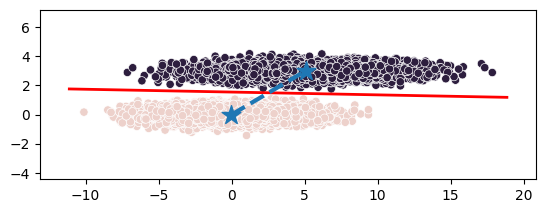

In [ ]:
# Задаём параметры для генерации точек
# Количество точек
n_points = np.array([10000, 10000])
target = np.array([-1, 1, 1])
# Среднее центров гауссианов
mean = np.array([[0, 0], [5, 3]])
# Матрицы коварианцй
cov = np.array(
    [[[6, 0],
      [0, 0.1]],
     [[10, 0],
      [0, 0.1]]]
    )
fisher_example(n_points, mean, cov, target)

## Порождающие модели в классификации

Перейдём от геометрической интерпретации к математической. 

Наша задача построить некоторую функцию $f(x;C_i)$ оценки принадлежности объекта каждому из классов. Для какого класса оценка выше, тому классу точка и будет принадлежать. Но вот большой вопрос: как обучить эти функции оценки, и какой они вообще должны иметь вид. 

Первая идея следует из теоремы Байеса и основана на генеративных моделях. Распишем вероятность принадлежности точки конкретному классу по теореме Байеса:

$$p(C_i|x)=\frac{p(x|C_i)p(C_i)}{p(x)}=\frac{p(x|C_i)p(C_i)}{\sum_{i=1}^{M}p(x|C_i)p(C_i)},$$
где $p(C_i)$ $-$ априорная вероятность принадлежности классу $C_i$, обычно их полагают равными, то есть предполагают равномерное априорное распределение классов. Иногда вероятности оценивают по имеющимся данным.

Более интересная же часть это $p(x|c_i)$ - распределение данных, принадлежащих классу $C_i$, то есть это порождающая модель, генерация данных из которой будет давать новые точки из заданного класса. Описанная же выше формула позволяет перейти от порождающих моделей к дискриминирующей модели $p(C_i|x)$. Если предположение о том, что $p(x|c_i)$ это действительно распределение имеющихся данных, то полученная дискриминирующая модель даст нам <b>оптимальный Байесовский классификатор</b> $-$ наилучшая модель классификации с точки зрения минимизации доли ошибок классификации.

Конечно, обучить настоящее распределение данных тяжело или невозможно, зато если предположить какую-то простую форму $p(x|c_i)$, то построить оптимальный байесовский классификатор станет уже вполне решаемой задачей.

Сделаем довольно сильное и простое предположение. Пусть $p(x|c_i) = N(x_j|m_k,\Sigma_k)$ это многомерное нормальное распределение. Такой метод построения разделяющей кривой называется <b>квадратичный дискриминантный анализ</b> (quadratic discriminative analysis, QDA).


Если дополнить предположение тем, что у распределений всех классов одинаковая матрица ковариации, то получаемый метод построения разделяющей кривой называется <b>линейный дискриминантный анализ</b> (linear discriminative analysis, LDA). 

Стоит отметить, что линейный дискриминантный анализ является обобщением дискриминанта Фишера на произвольное количество классов, а в применении к классификации на 2 категории они дают одинаковый ответ.

LDA мы уже применяли, посмотрим, как работает QDA.

In [ ]:
def QDA_example(n_points, mean, cov, target):
    X = []
    Y = []
    # Генерация точек из каждого гауссиана
    for i in range(0, n_points.shape[0]):
        X.append(np.random.multivariate_normal(mean=mean[i], cov=cov[i], size=n_points[i]))
        Y.append(np.ones(n_points[i])*target[i])
    X = np.concatenate(X)
    Y = np.concatenate(Y)
    # Обучение модели
    model = QuadraticDiscriminantAnalysis()
    model.fit(X, Y)

    # Границы отрисовки
    xmin, xmax = X[:,0].min()-3, X[:,0].max()+3
    ymin, ymax = X[:,1].min()-3, X[:,1].max()+3
    # 
    x = np.linspace(xmin, xmax, 300)
    y = np.linspace(ymin, ymax, 300)
    # создаём две матрицы с координатами x и y
    x, y = np.meshgrid(x, y)
    # Преобразуем матрицу в строчку
    xx = x.reshape(-1,1)
    yy = y.reshape(-1,1)
    points = np.hstack([xx,yy])
    # Передаём строчку точек в функцию
    probs = model.predict_proba(points)
    # Преобразуем строчку обратно в матрицу
    probs = probs[:, 0].reshape(x.shape)
    # рисуем контур функции
    plt.contour(x, y, probs, levels=[0.5])
    # рисование точек данных
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, legend=False)
    plt.gca().set_aspect("equal") # фиксированное соотношение сторон, чтобы сохранялись углы 90
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)

Давайте сравним LDA и QDA для гауссиан с разной ковариацией:

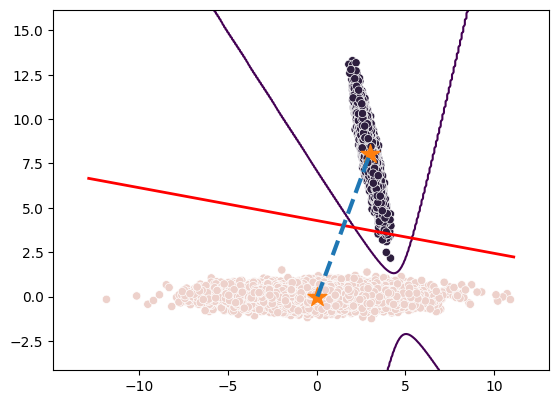

In [ ]:
# Задаём параметры для генерации точек
# Количество точек
n_points = np.array([10000, 10000])
target = np.array([1, 2])
# Среднее центров гауссианов
mean = np.array([[0, 0], [3, 8]])
# Матрицы коварианцй
cov = np.array(
    [[[6, 0],
      [0, 0.1]],
     [[0.1, -0.4],
      [-0.4, 2]]]
    )
QDA_example(n_points, mean, cov, target)
fisher_example(n_points, mean, cov, target)

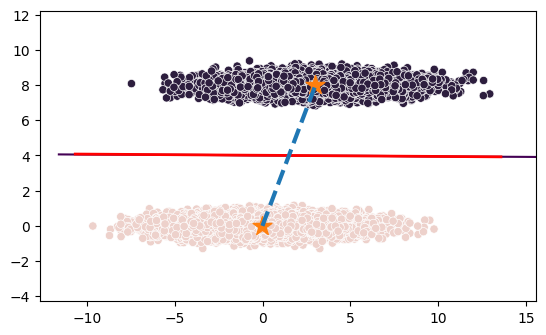

In [ ]:
# Задаём параметры для генерации точек
# Количество точек
n_points = np.array([10000, 10000])
target = np.array([1, 2])
# Среднее центров гауссианов
mean = np.array([[0, 0], [3, 8]])
# Матрицы коварианцй
cov = np.array(
    [[[6, 0],
      [0, 0.1]],
     [[6, 0],
      [0, 0.1]]]
    )
QDA_example(n_points, mean, cov, target)
fisher_example(n_points, mean, cov, target)

Как мы видим, LDA начинает совершать ошибки при классификации одного из классов, а QDA довольно хорошо отделяет их. 

Важно заметить, что QDA будет давать квадратические разделяющие поверхности, то есть, эллипсоиды, параболоиды и гиперболоиды. И в рассматриваемом примере мы получили именно гиперболоид, нижнюю часть которого видно на графике. Может показаться, что нижняя часть разделяющей кривой это ошибка, но вероятность принадлежности второму классу в той области и правда выше чем вероятность принадлежности первому. 

И слово "вероятность" применяется тут не просто так, построенная модель при выполнении предположения о нормальном распределении и правда выдаёт вероятность принадлежности точек классам.

In [ ]:
def QDA_example_multiclass(n_points, mean, cov, target):
    X = []
    Y = []
    # Генерация точек из каждого гауссиана
    for i in range(0, n_points.shape[0]):
        X.append(np.random.multivariate_normal(mean=mean[i], cov=cov[i], size=n_points[i]))
        Y.append(np.ones(n_points[i])*target[i])
    X = np.concatenate(X)
    Y = np.concatenate(Y)
    # Обучение модели
    model = QuadraticDiscriminantAnalysis()
    model.fit(X, Y)

    # Границы отрисовки
    xmin, xmax = X[:,0].min()-3, X[:,0].max()+3
    ymin, ymax = X[:,1].min()-3, X[:,1].max()+3
    x = np.linspace(xmin, xmax, 300)
    y = np.linspace(ymin, ymax, 300)
    # создаём две матрицы с координатами x и y
    x, y = np.meshgrid(x, y)
    # Преобразуем матрицу в строчку
    xx = x.reshape(-1,1)
    yy = y.reshape(-1,1)
    points = np.hstack([xx,yy])
    # Передаём строчку точек в функцию
    probs = model.predict_proba(points)
    # Преобразуем строчку обратно в матрицу
    probs = np.argmax(probs, axis=1).reshape(x.shape)
    # рисуем деление плоскости на классы
    plt.pcolormesh(x, y, probs, cmap="tab10",vmax=10)
    # рисование точек данных
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="bright", legend=False)
    plt.gca().set_aspect("equal") # фиксированное соотношение сторон, чтобы сохранялись углы 90
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)

А в случае с несколькими классами поверхность становится ещё более причудливой:

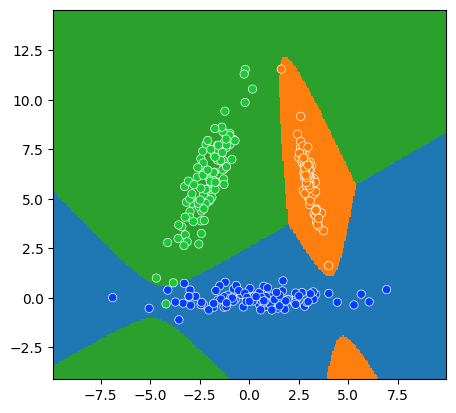

In [ ]:
# Задаём параметры для генерации точек
# Количество точек
n_points = np.array([100, 100, 100])
target = np.array([1, 2, 3])
# Среднее центров гауссианов
mean = np.array([[0, 0], [3, 6], [-2, 6]])
# Матрицы коварианцй
cov = np.array(
    [[[6, 0],
      [0, 0.1]],
     [[0.1, -0.4],
      [-0.4, 2]],
     [[1, 2],
      [2, 5]]]
    )
QDA_example_multiclass(n_points, mean, cov, target)

## Метод ближайших соседей KNN

Далее мы рассмотрим метод ближайших соседей (k-ближайших соседей, k-nearest neighbors, KNN), это непараметрический метод классификации, то есть он не обучает никаких распределений или функций оценки.

Метод основан на простой идее: соседние по некоторому расстоянию объекты, скорее всего принадлежат одному классу. Метод $k$ ближайших соседей состоит ровно в том, что мы находим для интересующей нас точки $k$ ближайших соседей, а далее происходит "голосование", определяющее результирующий класс. Далее опишем всё чуть более математически.

Имеются данные: $D = \{(x_i, t_i)\}_{i=1}^n$, где $x_i \in X$, $t_i \in \{1, \dots ,M\}$. $X$ $-$ некоторое метрическое пространство, то есть пространство на котором задано некоторое расстояние $d(x,y)$. Далее не делая никаких сложных предположений, выберем некоторую константу количества соседей $k$, тогда можно определить множества ближайших соседей для точки $x$: $NN_k(x)$. 

Далее на основании множества соседей $NN_k(x)$ определяется предсказание $\hat{t}$. Обычно это определяется голосованием:

$$\hat{t}=\arg \max_{m=1,\dots, M} \#\{x_n\in NN_k(x)\mid t_n=m\}.$$

Это голосование можно организовать с разными весами для разных участников:

$$\hat{t}=\arg \max_{m=1,\dots, M} \sum_{x_n\in NN_k(x): t_n=m}w_n.$$

Веса $w_n$ можно определять по разному, но скорее всего, мы захотим сделать так, чтобы веса были обратно пропорциональны расстоянию:

$$\hat{t}=\arg \max_{m=1,\dots, M} \sum_{x_n\in NN_k(x): t_n=m}\frac{1}{d(x,x_n)}.$$

Метод ближайших соседей можно применять не только для классификации, но и для регрессии. Пусть данные это пары $(x_n, y_n)$, тогда предсказания для $x$ определяется как среднее по ближайшим соседям:

$$\hat{t}=\frac{1}{k}\sum_{x_n\in NN_k(x)}y_n.$$

В этом случае можно также ввести веса, но необходимо, чтобы ответ формировался как выпуклая комбинация целевой переменной соседей:

$$\hat{t}=\sum_{x_n\in NN_k(x)}w_ny_n, \;\; \text{где} \sum_{x_n\in NN_k(x)}w_n=1$$

Помимо выбора весов и количество соседей $k$ результат работы метода также сильно будет зависеть от выбора расстояния. Рассмотри основные варианты расстояний:

- Евклидово расстояние, которое чаще всего берут, когда $x_n\in\R^n$:
    $$d(x_1,x_2) = \sqrt{(x_1-x_2)^T(x_1-x_2)} = \sqrt{\sum_{i=1}^d(x_{1i}-x_{2i})^2};$$
- расстояние Минковского, являющееся обобщением расстояния Евклида:
    $$d(x_1,x_2) = \left(\sum_{i=1}^d(x_{1i}-x_{2i})^p\right)^{1/p};$$
- Манхеттеноское расстояние, являющееся частным случаем расстояния Минковского: 
    $$d(x_1,x_2) = \sum_{i=1}^d|x_{1i}-x_{2i}|;$$
- косинусная похожесть, применяемая для сравнения степени похожести векторов:
    $$cos(x_1,x_2)=\frac{x_1^Tx_2}{|x_1|\cdot|x_2|}.$$
    Но косинус имеет значения от -1 до 1 и отражает похожесть, нам нужно инвертировать значение, поэтому определим расстояние:
    $$d(x_1,x_2)=1-cos(x_1,x_2);$$
- расстояние Хэмминга используется когда значения принадлежат дискретному пространству и состоят из битов, символов или других категориальных значений. Это расстояние очень полезно при сравнении строк:
    $$d(x_1,x_2)=\sum_{i=1}^{d}\mathbb{I}[x_{1i}\neq x_{2i}];$$
 
- Коэффициент Жаккара полезен при сравнении множеств:
    $$d(A,B)=\frac{|A\cap B|}{|A\cup B|} = \frac{|A\cap B|}{|A|+|B|- |A\cap B|}.$$

Далее воспользуемся библиотекой scikit-Learn чтобы применить уже готовый метод ближайших соседей. Но перед этим сделаем небольшое отступление. Тестировать методы теперь мы будем не на сгенерированных данных, а на настоящем наборе данных. Мы возьмём набор данных, называемый Ирисами Фишера. Стандартный набор данных для демонстрации работы методов классификации.

In [ ]:
def knn_example(k_neighbors, n_points, mean, cov, target):
    X = []
    Y = []
    # Генерация точек из каждого гауссиана
    for i in range(0, n_points.shape[0]):
        X.append(np.random.multivariate_normal(mean=mean[i], cov=cov[i], size=n_points[i]))
        Y.append(np.ones(n_points[i])*target[i])
    X = np.concatenate(X)
    Y = np.concatenate(Y)
    # Обучение модели
    model = KNeighborsClassifier(k_neighbors)
    model.fit(X, Y)

    # Границы отрисовки
    xmin, xmax = X[:,0].min()-3, X[:,0].max()+3
    ymin, ymax = X[:,1].min()-3, X[:,1].max()+3
    x = np.linspace(xmin, xmax, 300)
    y = np.linspace(ymin, ymax, 300)
    # создаём две матрицы с координатами x и y
    x, y = np.meshgrid(x, y)
    # Преобразуем матрицу в строчку
    xx = x.reshape(-1,1)
    yy = y.reshape(-1,1)
    points = np.hstack([xx,yy])
    # Передаём строчку точек в функцию
    probs = model.predict(points)
    # Преобразуем строчку обратно в матрицу
    probs = probs.reshape(x.shape)
    # рисуем деление плоскости на классы
    plt.pcolormesh(x, y, probs, cmap="tab10",vmax=10)
    # рисование точек данных
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="bright", legend=False)
    plt.gca().set_aspect("equal") # фиксированное соотношение сторон, чтобы сохранялись углы 90
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)

При довольно отдалённых классах всё просто:

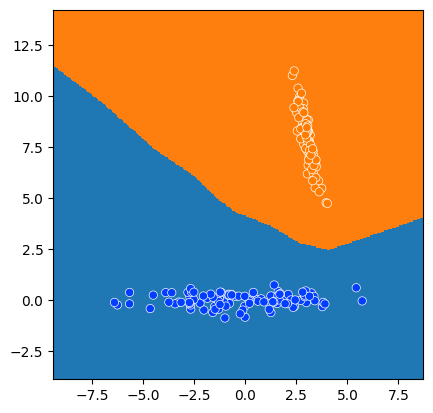

In [ ]:
# Задаём параметры для генерации точек
# Количество точек
n_points = np.array([100, 100])
target = np.array([1, 2])
# Среднее центров гауссианов
mean = np.array([[0, 0], [3, 8]])
# Матрицы коварианцй
cov = np.array(
    [[[6, 0],
      [0, 0.1]],
     [[0.1, -0.4],
      [-0.4, 2]]]
    )
knn_example(1, n_points, mean, cov, target)

Но при большом шуме в данных получаемая разделяющая поверхность при $k=1$ получается довольно "рваной". Модель получается переобученной, склонной следовать за каждой точкой данных.

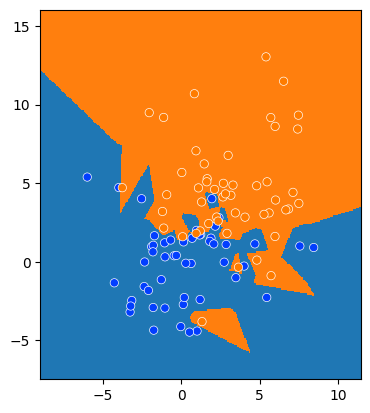

In [ ]:
# Задаём параметры для генерации точек
# Количество точек
n_points = np.array([50, 50])
target = np.array([1, 2])
# Среднее центров гауссианов
mean = np.array([[0, 0], [3, 5]])
# Матрицы коварианцй
cov = np.array(
    [[[6, 0],
      [0, 6]],
     [[7, -0.4],
      [-0.4, 7]]]
    )
knn_example(1, n_points, mean, cov, target)

Про повышении количества соседей поверхность становится более гладкой.

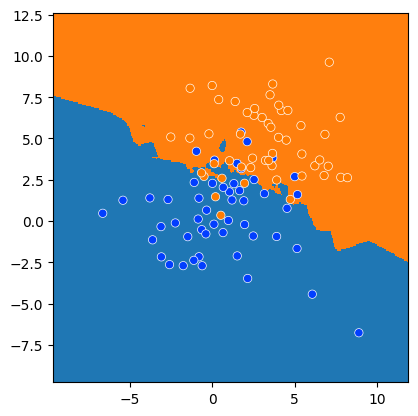

In [ ]:
# Задаём параметры для генерации точек
# Количество точек
n_points = np.array([50, 50])
target = np.array([1, 2])
# Среднее центров гауссианов
mean = np.array([[0, 0], [3, 5]])
# Матрицы коварианцй
cov = np.array(
    [[[6, 0],
      [0, 6]],
     [[7, -0.4],
      [-0.4, 7]]]
    )
knn_example(11, n_points, mean, cov, target)

При разном масштабе признаков и большом количестве соседей можно получить гладкую, но плохо подходящую разделяющую поверхность.

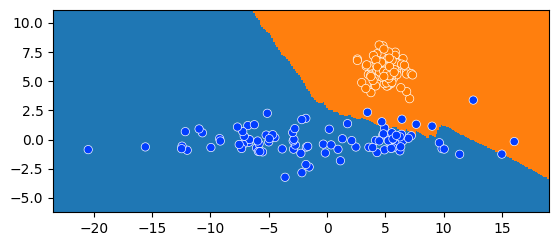

In [ ]:
# Задаём параметры для генерации точек
# Количество точек
n_points = np.array([100, 100])
target = np.array([1, 2])
# Среднее центров гауссианов
mean = np.array([[0, 0], [5, 6] ])
# Матрицы коварианцй
cov = np.array(
    [[[40, 0],
      [0, 1]],
     [[1, 0],
      [0, 1]]]
    )
knn_example(77, n_points, mean, cov, target)

## Алгоритмы поиска ближайших соседей

Как мы уже отметили, для работы метода ближайших соседей потребуется хранить весь набор данных. Остаётся важный вопрос: как искать ближайших соседей? Как мы уже отмечали, наборы данных в машинном обучении могут быть огромны и нам не хотелось бы каждый раз перебирать все точки данных, чтобы найти $k$ ближайших соседей. В реализации sci-kit learn есть 3 алгоритма на выбор:

- brute $-$ перебор всех точек данных
- ball_tree $-$ метод, основанный на построении шарового дерева. Кратко описать алгоритм можно так:
    - в корне дерева находится множество всех точек данных, оно характеризуется центроидом, равным среднему всех точек,
    - в качестве центра первого кластера выберем точку, наиболее отстоящую от центра, а в качестве центра второго кластера $-$ точку, наиболее далёкую от первой,
    - разделяем все точки на две части, относя каждую точку к ближайшему центру,
    - повторяем процесс рекурсивно, пока не достигнем заданной глубины дерева.
    
    такой подход позволяет найти подмножество точек, лежащих неподалёку от заданной, и искать ближайших соседей уже среди них.

- kd_tree $-$ метод, основанный на построении k-d-деревьев. Метод похож на предыдущий метод, но каждый раз использует только одну координату. Описать его можно так:
    - в корне дерева находятся все точки данных. Упорядочим точки по первым координатам вектора,
    - найдём медиану по первой координате, разделим точки на 2 кластера $-$ на те, которые больше и меньше медианы.
    - разделяем каждый из полученных кластеров, но уже по второй координате.
    - и так далее, пока не достигнем необходимой глубины дерева.

Для небольших размерностей k-d-деревья работают лучше, поскольку строят сбалансированное (по количеству точек) дерево, но с ростом размерности шаровые деревья становятся более предпочтительны. Есть и другие алгоритмы и есть целая наука посвящённая тому, как искать ближайших соседей. Есть разные алгоритмы, дающие приближенный ответ (могут не найти какое-то количество соседей), тем не менее в задачах с большой размерностью и большим количеством признаков метод ближайших соседей становится не применим как из-за необходимости хранить весь набор данных, так и из-за более серьёзных математических проблем, с которыми вы познакомитесь на лекциях.


## KNN для регрессии

Как мы уже отмечали, метод ближайших соседей можно использовать и для решения задачи регрессии.

In [ ]:
# генерируем данные для тестов
function = lambda x: np.sin(x)+x*0.3

xmin,xmax = 0, 20
n_samples = 20

X = np.linspace(xmin, xmax, n_samples)
Y = function(X)+np.random.normal(0, 1, n_samples)

В случае одного соседа мы получим кусочно-постоянную функцию.

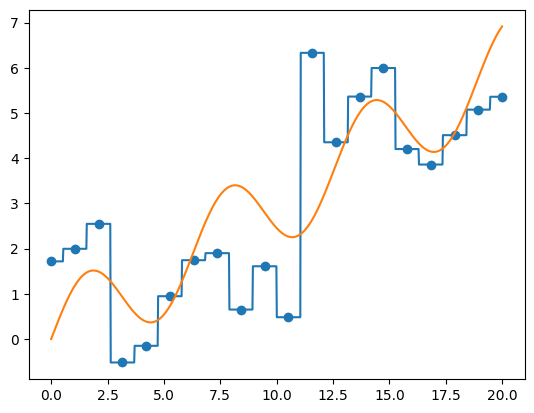

In [ ]:
model = KNeighborsRegressor(n_neighbors=1)

model.fit(X[:,None],Y)
plt.scatter(X, Y)
t= np.linspace(xmin,xmax,1000)
plt.plot(t, model.predict(t[:,None]))
plt.plot(t, function(t))

При большем количестве соседей:

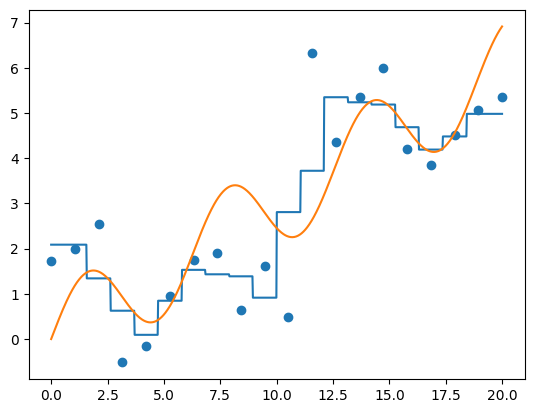

In [ ]:
model = KNeighborsRegressor(n_neighbors=3)

model.fit(X[:,None],Y)
plt.scatter(X, Y)
t= np.linspace(xmin,xmax,1000)
plt.plot(t, model.predict(t[:,None]))
plt.plot(t, function(t))

Если возьмём два соседа и веса будем распределять в зависимости от расстояния, то, в случае равных расстояний между точками, получим линейные сплайны:

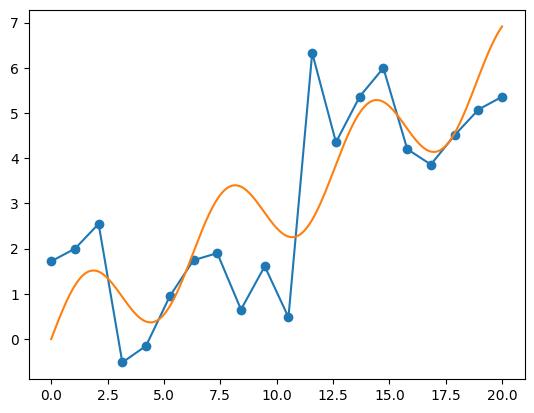

In [ ]:
model = KNeighborsRegressor(n_neighbors=2, weights="distance")

model.fit(X[:,None],Y)
plt.scatter(X, Y)
t= np.linspace(xmin,xmax,1000)
plt.plot(t, model.predict(t[:,None]))
plt.plot(t, function(t))

Если количество соседей увеличивать, то с получаемой зависимостью происходят что-то неприятное. Она вся становится ломаной и "равной". Причиной этому является изменение множества ближайших соседей, поэтому происходит резкое изменение предсказания модели.

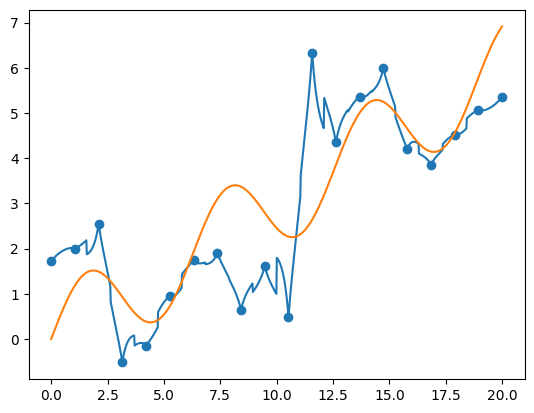

In [ ]:
model = KNeighborsRegressor(n_neighbors=3, weights="distance")

model.fit(X[:,None],Y)
plt.scatter(X, Y)
t= np.linspace(xmin,xmax,1000)
plt.plot(t, model.predict(t[:,None]))
plt.plot(t, function(t))

А при чётном количестве соседей, таких изломов происходить не будет, так как точка изменения множества ближайших соседей будет совпадать в точками данных, где предсказание модели в точности совпадают с самой точкой.

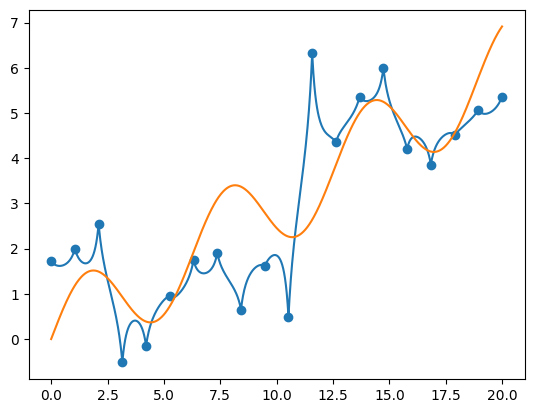

In [ ]:
model = KNeighborsRegressor(n_neighbors=6, weights="distance")

model.fit(X[:,None],Y)
plt.scatter(X, Y)
t= np.linspace(xmin,xmax,1000)
plt.plot(t, model.predict(t[:,None]))
plt.plot(t, function(t))

In [ ]:
# генерируем данные для тестов
function = lambda x: np.sin(x)+x*0.3

xmin,xmax = 0, 20
n_samples = 100

X = np.random.uniform(xmin, xmax, n_samples)
Y = function(X) + np.random.normal(0, 1, n_samples)

Теперь посмотрим результаты модели на случайно разбросанных точках:

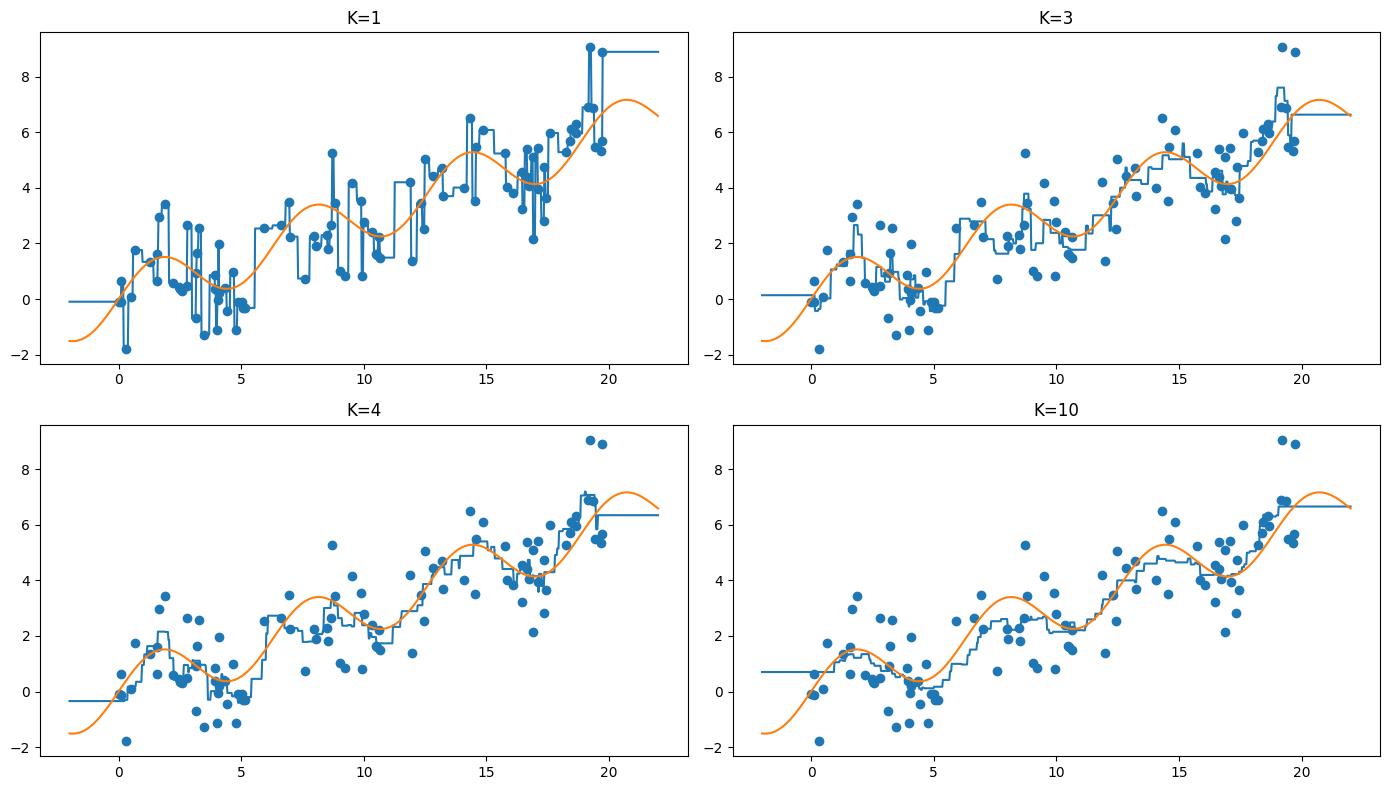

In [ ]:
k_arr = [1,3,4,10]

fig,axes = plt.subplots(2,2)
fig.set_size_inches(14,8)
axes=axes.flatten()
for index, k in enumerate(k_arr):
    model = KNeighborsRegressor(n_neighbors=k)

    model.fit(X[:,None],Y)
    axes[index].scatter(X, Y)
    t= np.linspace(xmin-2,xmax+2,1000)
    axes[index].plot(t, model.predict(t[:,None]))
    axes[index].plot(t, function(t))
    axes[index].set_title(f"K={k}")
fig.tight_layout()

При установлении весов в зависимости от расстояния, мы всё также будем получать переобученные модели, дающие идеальные ответы на обучающем множестве, но совсем не релевантные для других точек.

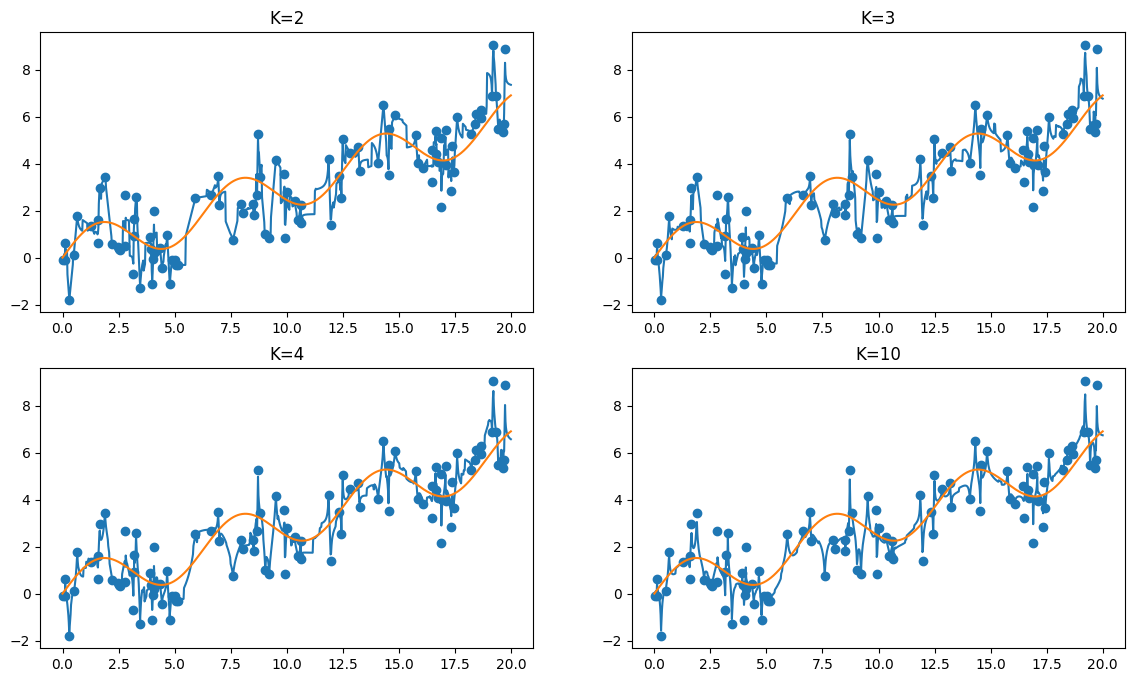

In [ ]:
k_arr = [2, 3, 4, 10]

fig,axes = plt.subplots(2,2)
fig.set_size_inches(14,8)
axes=axes.flatten()
for index, k in enumerate(k_arr):
    model = KNeighborsRegressor(n_neighbors=k, weights="distance")

    model.fit(X[:,None],Y)
    axes[index].scatter(X, Y)
    t= np.linspace(xmin,xmax,1001)
    axes[index].plot(t, model.predict(t[:,None]))
    axes[index].plot(t, function(t))
    axes[index].set_title(f"K={k}")

Мы также можем определять веса по-своему. Мы можем распределить веса в линейной зависимости. Для этого необходимо определить функцию назначения весов:

In [ ]:
def lin_weights(distance):
    #  distance это матрица расстояний размера (n_points,k)
    # n_points - количество точек, для которых происходит предсказание
    # k - количество соседей
    # В каждой ячейке записано расстояние от точки до ближайших соседей
    ret = np.zeros_like(distance)
    k = ret.shape[1]
    for i in range(k):
        ret[:, i] = (k-i) # Присваиваем линейно убывающие веса
    return ret

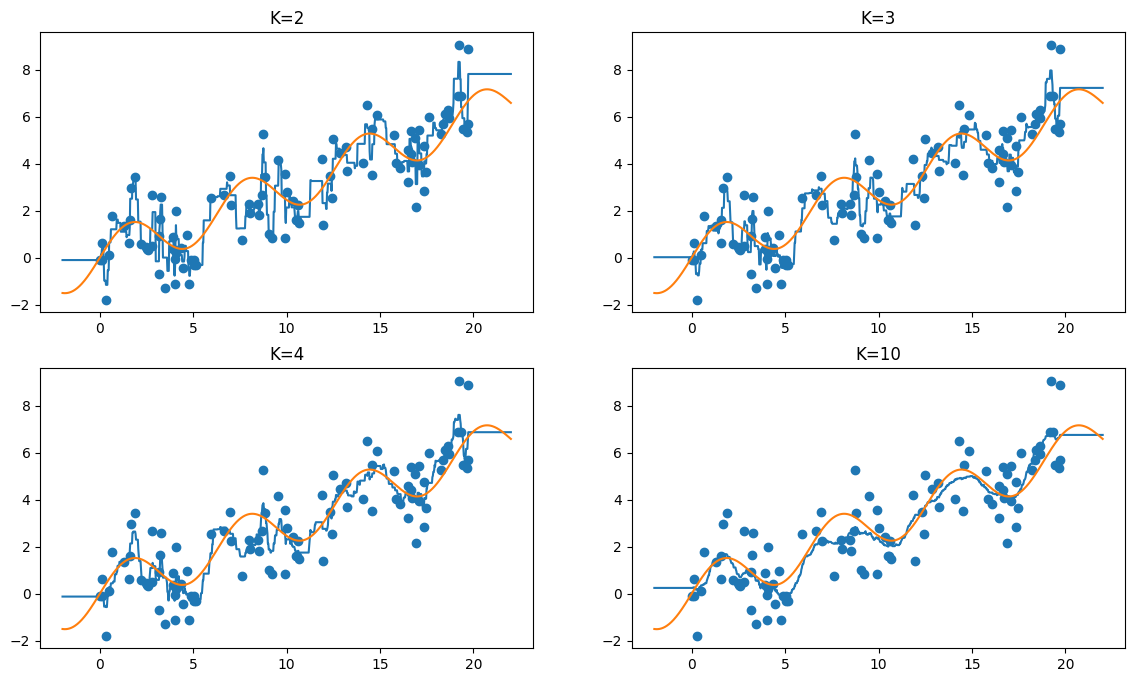

In [ ]:
k_arr = [2, 3, 4, 10]

fig,axes = plt.subplots(2,2)
fig.set_size_inches(14,8)
axes=axes.flatten()
for index, k in enumerate(k_arr):
    model = KNeighborsRegressor(n_neighbors=k, weights=lin_weights)

    model.fit(X[:,None],Y)
    axes[index].scatter(X, Y)
    t= np.linspace(xmin-2,xmax+2,1001)
    axes[index].plot(t, model.predict(t[:,None]))
    axes[index].plot(t, function(t))
    axes[index].set_title(f"K={k}")

## Проблемы KNN

- Из-за того, что метод ближайших соседей основан на вычислении расстояния, то он очень чувствителен к масштабу признаков. Разные признаки будут давать разный вклад в расстояние, а поскольку метод непараметрический, то влияние никак не может быть скорректированной моделью самостоятельно. Необходимо масштабировать признаки, это мы ранее уже делали, к примеру с использованием `StandardScaler`.

- Метод ближайших соседей склонен к переобучению. Он слабо устойчив к шуму и выбросам.

## Нечёткая классификация методом ближайшего соседа

Важно отметить, что метод ближайшего соседа не оценивает вероятность принадлежности объектов классам, а даёт жёсткий ответ. Это является довольно значимым недостатком. Хотелось бы, чтобы модель машинного обучения давала не только ответ, но ещё и свою уверенность в ответе. Точка данных может оказаться как на границе переходов между классами, так и вовсе не соответствующей распределению данных. 

Для таких "умных" задач есть методы получше, которые получают вероятности естественным способом. Но из-за своей популярности и простоты, метод ближайшего соседа получил модификацию, называемую Fuzzy-knn. 

Принадлежность класса мы будем кодировать вектором $u$, причём $\sum_{j=1}^Mu_j=1$, $\forall j: u_j>0$. Для вектора $x_i$ из обучающей выборки $u_{ij}=1$, если этот объект принадлежит классу $j$.

Далее принадлежность объекта $x$ к классу $j$ мы будем определять по следующей формуле:

$$u_j(x)=\frac{\sum_{i=1}^ku_{ij}\left(\frac{1}{d(x,x_i)}\right)^{\frac{2}{m-1}}}{\sum_{i=1}^k\left(\frac{1}{d(x,x_i)}\right)^{\frac{2}{m-1}}}$$

Чаще всего параметр $m$ берут равным 2. Если устремить $m$ к $+\infty$, то веса каждого из ближайших соседей получатся равными, а если устремить $m$ к 1, то влияние самого близкого из соседей будет расти на фоне остальных.

Стоит отметить, что полученная оценка принадлежности ни в коем случае не является вероятностью. Метод не ставит никакого вероятностного предположения, он основан лишь на простой идее взвешенного голосования, где в ответе выдаётся не прямой ответ, а доля голосов за каждый класс.

И к сожалению в sci-kit learn нет реализации Fuzzy-knn. Зато есть на [github](https://github.com/sahilsehwag/FuzzyKNN/tree/master) Воспользуемся этой реализацией. Хоть она и является очень неудачной.

In [ ]:
from fknn import FuzzyKNN

iris_df = pd.read_csv("/home/ivanbalashov/Downloads/fife/Iris.csv", index_col="Id") 

X = iris_df[["SepalLengthCm", "SepalWidthCm"]].to_numpy()
encoder = LabelEncoder()
Y = encoder.fit_transform(iris_df["Species"])

model = FuzzyKNN(31) # Попробуйте поставить чётное число. Автор решил что чётное нельзя.
model.fit(X, Y)
xmin, xmax = X[:, 0].min() - 1, X[:, 0].max() + 1
ymin, ymax = X[:, 1].min() - 1, X[:, 1].max() + 1
x_ = np.linspace(xmin, xmax, 22)
y_ = np.linspace(ymin, ymax, 22)
xx , yy = np.meshgrid(x_, y_)
xx_ = xx.reshape(-1, 1)
yy_ = yy.reshape(-1, 1)
points = np.hstack([xx_,yy_])
rez = model.predict(points)
rez

[(np.int64(0),
  {np.int64(0): np.float64(0.6162092530985477),
   np.int64(1): np.float64(0.3280114784607038),
   np.int64(2): np.float64(0.055779268440748465)}),
 (np.int64(0),
  {np.int64(0): np.float64(0.5780782668052328),
   np.int64(1): np.float64(0.3493620155907139),
   np.int64(2): np.float64(0.07255971760405304)}),
 (np.int64(0),
  {np.int64(0): np.float64(0.5361831463478631),
   np.int64(1): np.float64(0.3861921153359961),
   np.int64(2): np.float64(0.0776247383161406)}),
 (np.int64(0),
  {np.int64(0): np.float64(0.46472290323932014),
   np.int64(1): np.float64(0.43371217471644447),
   np.int64(2): np.float64(0.10156492204423544)}),
 (np.int64(1),
  {np.int64(0): np.float64(0.39078669145839895),
   np.int64(1): np.float64(0.4980168522448129),
   np.int64(2): np.float64(0.11119645629678805)}),
 (np.int64(1),
  {np.int64(0): np.float64(0.25206270511549667),
   np.int64(1): np.float64(0.590983364621736),
   np.int64(2): np.float64(0.15695393026276733)}),
 (np.int64(1),
  {np.int6

Библиотека выдаёт потрясающий ответ: список пар из чисел и словарей. 

Важно отметить, что в реализации не используются ни один из упомянутых алгоритмов быстрого поиска соседей, расстояние считается до всех точек данных, а потом производится сортировка.

Отобразим степени принадлежности классам:

(1.0, 5.4)

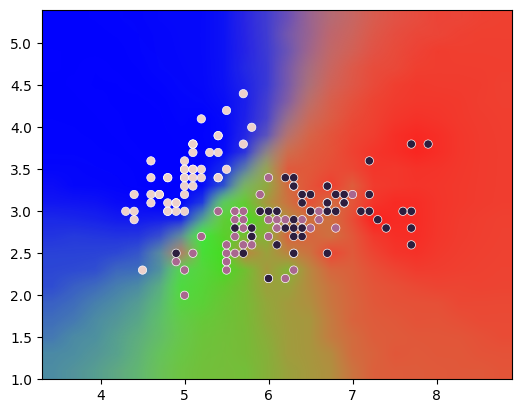

In [ ]:
probs = np.array([[val for val in item[1].values()] for item in rez]).reshape((*(xx.shape), 3))

o = np.ones_like(xx)
z = np.zeros_like(xx)

plt.imshow(np.stack([z, z, o], axis=2), alpha=probs[:, :, 0], extent=[xmin, xmax, ymax, ymin], interpolation="bilinear")
plt.imshow(np.stack([z, o, z], axis=2), alpha=probs[:, :, 1], extent=[xmin, xmax, ymax, ymin], interpolation="bilinear")
plt.imshow(np.stack([o, z, z], axis=2), alpha=probs[:, :, 2], extent=[xmin, xmax, ymax, ymin], interpolation="bilinear")
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=Y,legend=False)
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

# Домашнее задание

- Загрузите набор данных Ирисов Фишера. Примените линейный и квадратичный дискриминантный анализ. Сравните результаты. 
- Загрузите набор данных Ирисов Фишера. Попробуйте подобрать "на глаз" наилучшие параметры для метода kNN.
- Примените метод `RadiusNeighborsClassifier` из sci-kit learn. Почитайте про него в [документации](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.RadiusNeighborsClassifier.html#sklearn.neighbors.RadiusNeighborsClassifier). Как работает этот метод? Какие недостатки есть у данного метода?

Код для загрузки данных Ирисов Фишера:

In [ ]:
iris_df = pd.read_csv("./iris.csv", index_col="Id") 

X = iris_df[["SepalLengthCm", "SepalWidthCm"]].to_numpy()
encoder = LabelEncoder()
Y = encoder.fit_transform(iris_df["Species"])